In [1]:
# Cell 1: Run the C++ simulation
import subprocess
import os
import numpy as np
import matplotlib.pyplot as plt

# Define paths
cpp_exe = r'C:\Users\Owner\Documents\Repos\Fracture\MulticracksCpp\cpp\crack_simulation.exe'
output_dir = r'C:\Users\Owner\Documents\Repos\Fracture\MulticracksCpp\output'

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Run the C++ simulation
print("Running C++ simulation...")
result = subprocess.run([cpp_exe], capture_output=True, text=True, cwd=os.path.dirname(cpp_exe))

# Display output
print(result.stdout)
if result.stderr:
    print("Errors:", result.stderr)

print("\nSimulation complete!")

Running C++ simulation...
Initialized 5 cracks, 80 dislocations


=== Step 0: Applied Stress = 50 MPa ===
  Propagations: 0
  Mean: 3.82474 um, Max: 4.67703 um
  Wrote C:/Users/Owner/Documents/Repos/Fracture/MulticracksCpp/output/field_0.dat

=== Step 1: Applied Stress = 75 MPa ===
  Propagations: 0
  Mean: 3.82474 um, Max: 4.67703 um

=== Step 2: Applied Stress = 100 MPa ===
  Propagations: 0
  Mean: 3.82474 um, Max: 4.67703 um
  Wrote C:/Users/Owner/Documents/Repos/Fracture/MulticracksCpp/output/field_2.dat

=== Step 3: Applied Stress = 125 MPa ===
  Propagations: 0
  Mean: 3.82474 um, Max: 4.67703 um

=== Step 4: Applied Stress = 150 MPa ===
  Propagations: 0
  Mean: 3.82474 um, Max: 4.67703 um
  Wrote C:/Users/Owner/Documents/Repos/Fracture/MulticracksCpp/output/field_4.dat

=== Step 5: Applied Stress = 175 MPa ===
  Propagations: 0
  Mean: 3.82474 um, Max: 4.67703 um

=== Step 6: Applied Stress = 200 MPa ===
  Propagations: 0
  Mean: 3.82474 um, Max: 4.67703 um
  Wrote C:/Users/Ow

In [2]:
# Cell 2: Define plotting function
def plot_stress_field(filename, stress_component='sigma_yy', output_png=None):
    """Plot stress field from data file"""
    
    # Load data
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    grid_data = []
    crack_data = []
    mode = 'grid'
    
    for line in lines:
        parts = line.strip().split()
        if not parts:
            continue
        values = [float(x) for x in parts]
        
        if values[0] == -999:
            mode = 'crack'
            continue
        elif values[0] == -998:
            break
        
        if mode == 'grid':
            grid_data.append(values)
        elif mode == 'crack':
            crack_data.append(values)
    
    grid = np.array(grid_data)
    cracks = np.array(crack_data) if crack_data else np.array([])
    
    # Extract data
    x, y = grid[:, 0], grid[:, 1]
    sigma_xx, sigma_yy, sigma_xy = grid[:, 2], grid[:, 3], grid[:, 4]
    
    # Grid dimensions
    unique_x, unique_y = np.unique(x), np.unique(y)
    nx, ny = len(unique_x), len(unique_y)
    
    X, Y = x.reshape(ny, nx), y.reshape(ny, nx)
    
    # Select component
    if stress_component == 'sigma_xx':
        Z = sigma_xx.reshape(ny, nx) / 1e6
        label = r'$\sigma_{xx}$ (MPa)'
    elif stress_component == 'sigma_yy':
        Z = sigma_yy.reshape(ny, nx) / 1e6
        label = r'$\sigma_{yy}$ (MPa)'
    else:
        Z = sigma_xy.reshape(ny, nx) / 1e6
        label = r'$\sigma_{xy}$ (MPa)'
    
    # Create plot
    fig, ax = plt.subplots(figsize=(12, 10))
    
    vmax = np.percentile(np.abs(Z), 98)
    vmin = -vmax
    levels = np.linspace(vmin, vmax, 40)
    
    contourf = ax.contourf(X*1e6, Y*1e6, Z, levels=levels, cmap='RdBu_r', extend='both')
    contours = ax.contour(X*1e6, Y*1e6, Z, levels=12, colors='black', 
                         linewidths=0.5, alpha=0.4)
    ax.clabel(contours, inline=True, fontsize=8, fmt='%1.0f')
    
    cbar = plt.colorbar(contourf, ax=ax, label=label, pad=0.02, shrink=0.9)
    
    # Plot cracks
    if len(cracks) > 0:
        for i, crack in enumerate(cracks):
            cx, cy, length, angle = crack
            dx, dy = length/2 * np.cos(angle), length/2 * np.sin(angle)
            x1, y1 = (cx - dx)*1e6, (cy - dy)*1e6
            x2, y2 = (cx + dx)*1e6, (cy + dy)*1e6
            
            ax.plot([x1, x2], [y1, y2], 'k-', linewidth=5, zorder=100)
            ax.plot([x1, x2], [y1, y2], 'w-', linewidth=2.5, zorder=101)
            ax.text(cx*1e6, cy*1e6, f'{i}', fontsize=10, ha='center',
                   color='black', weight='bold', zorder=102,
                   bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))
    
    ax.set_xlabel('X (μm)', fontsize=13, weight='bold')
    ax.set_ylabel('Y (μm)', fontsize=13, weight='bold')
    ax.set_title(label, fontsize=15, weight='bold', pad=15)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.25, linestyle='--')
    ax.axhline(0, color='k', linewidth=0.5, alpha=0.3)
    ax.axvline(0, color='k', linewidth=0.5, alpha=0.3)
    
    plt.tight_layout()
    
    if output_png:
        plt.savefig(output_png, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Saved: {output_png}")
    
    plt.show()

Found 6 data files

Step 0


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

Saved: C:\Users\Owner\Documents\Repos\Fracture\MulticracksCpp\output\sigma_yy_step0.png


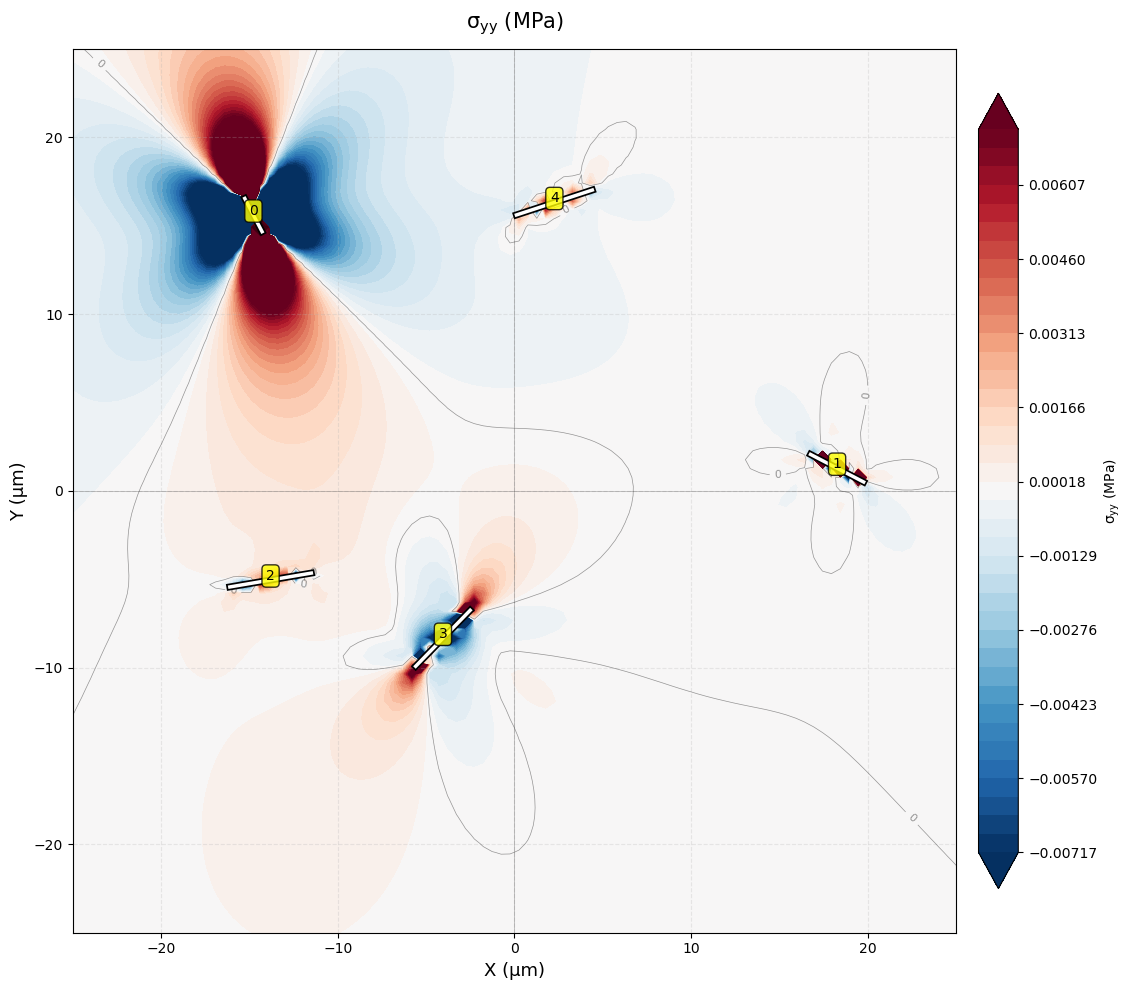

Saved: C:\Users\Owner\Documents\Repos\Fracture\MulticracksCpp\output\sigma_xx_step0.png


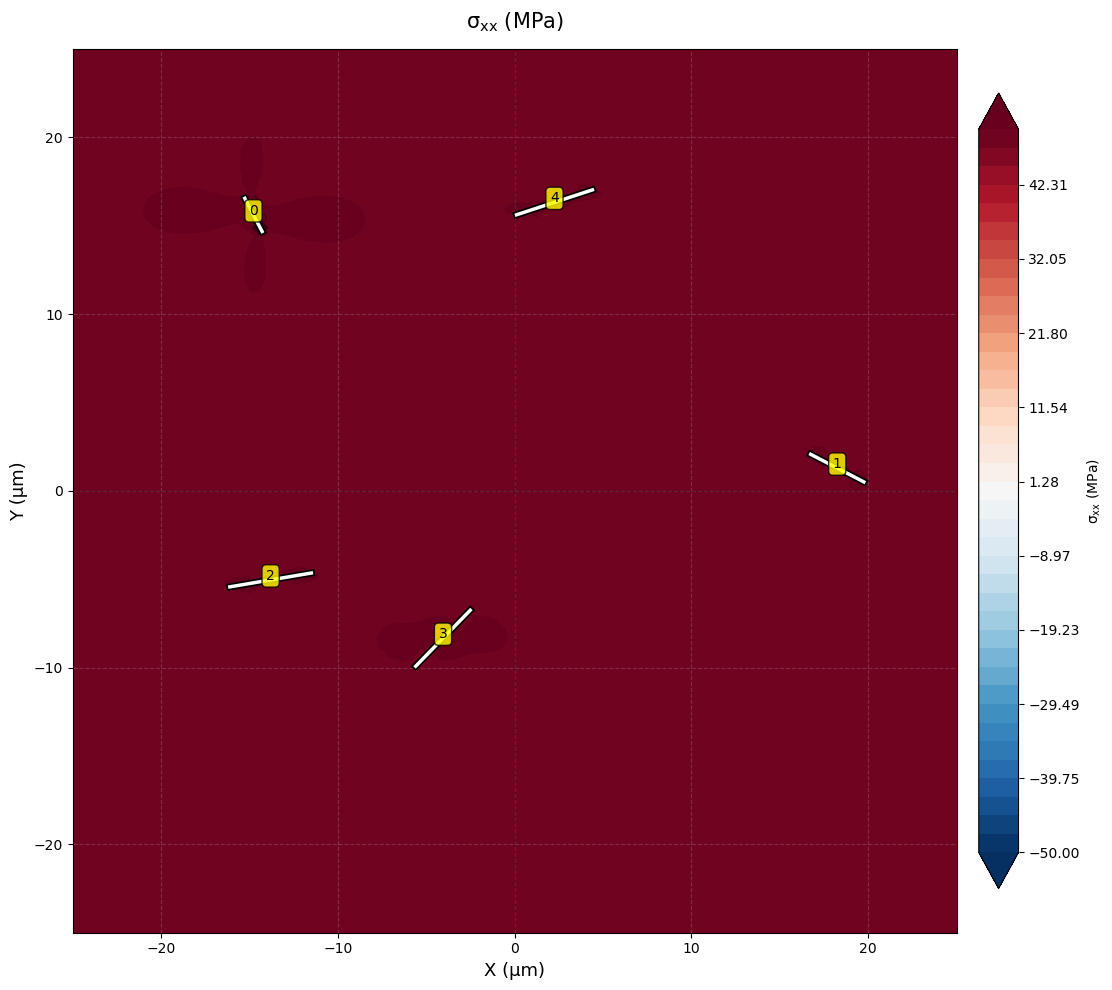


Step 2
Saved: C:\Users\Owner\Documents\Repos\Fracture\MulticracksCpp\output\sigma_yy_step2.png


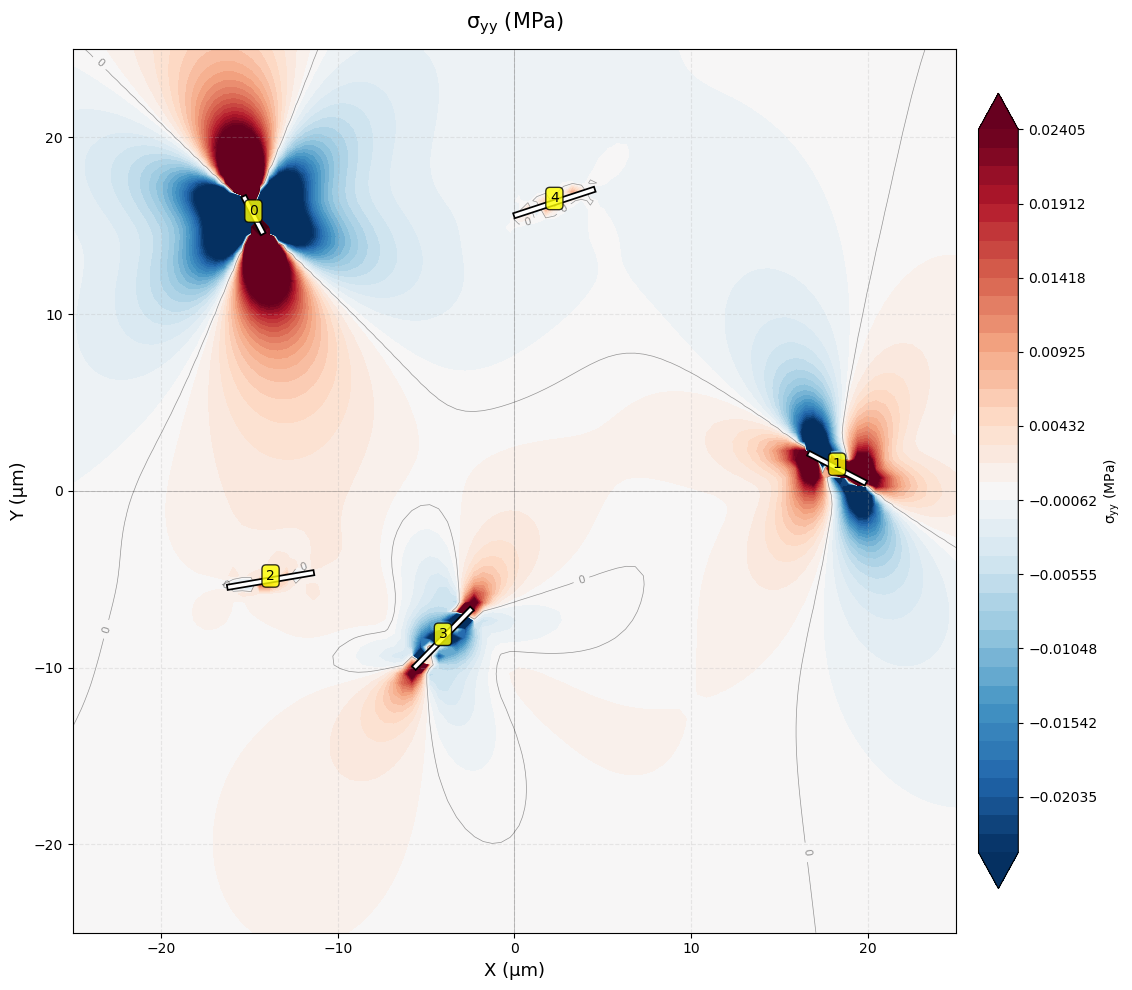

Saved: C:\Users\Owner\Documents\Repos\Fracture\MulticracksCpp\output\sigma_xx_step2.png


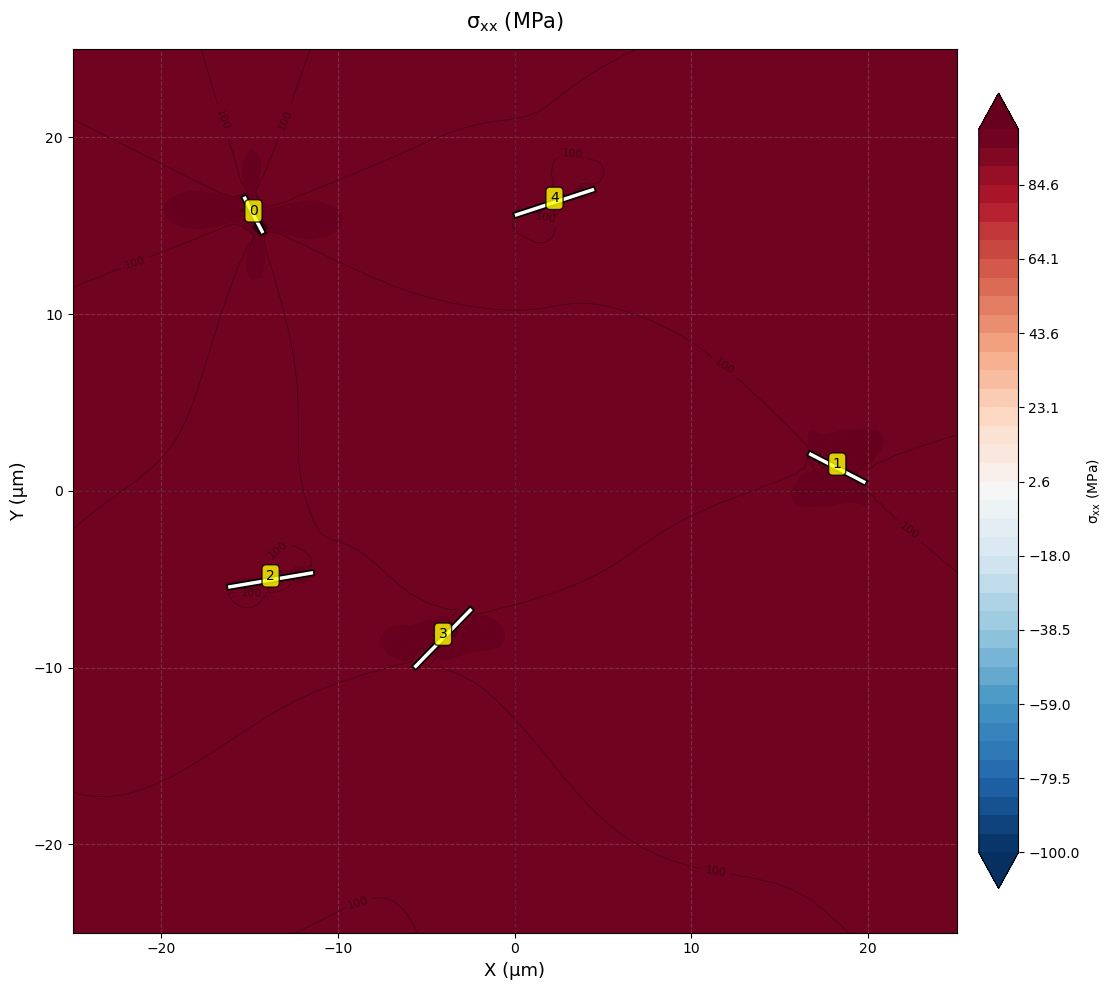


Step 4
Saved: C:\Users\Owner\Documents\Repos\Fracture\MulticracksCpp\output\sigma_yy_step4.png


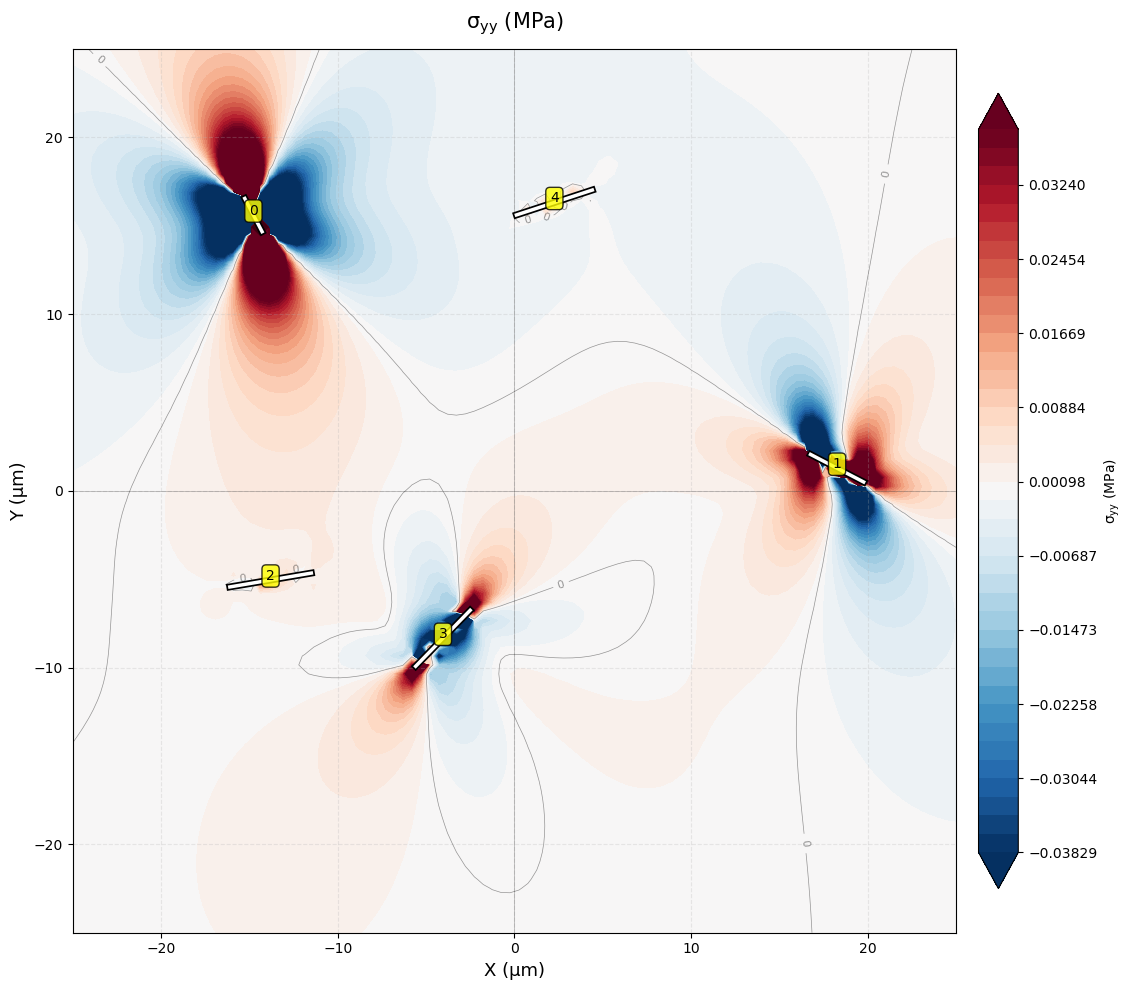

Saved: C:\Users\Owner\Documents\Repos\Fracture\MulticracksCpp\output\sigma_xx_step4.png


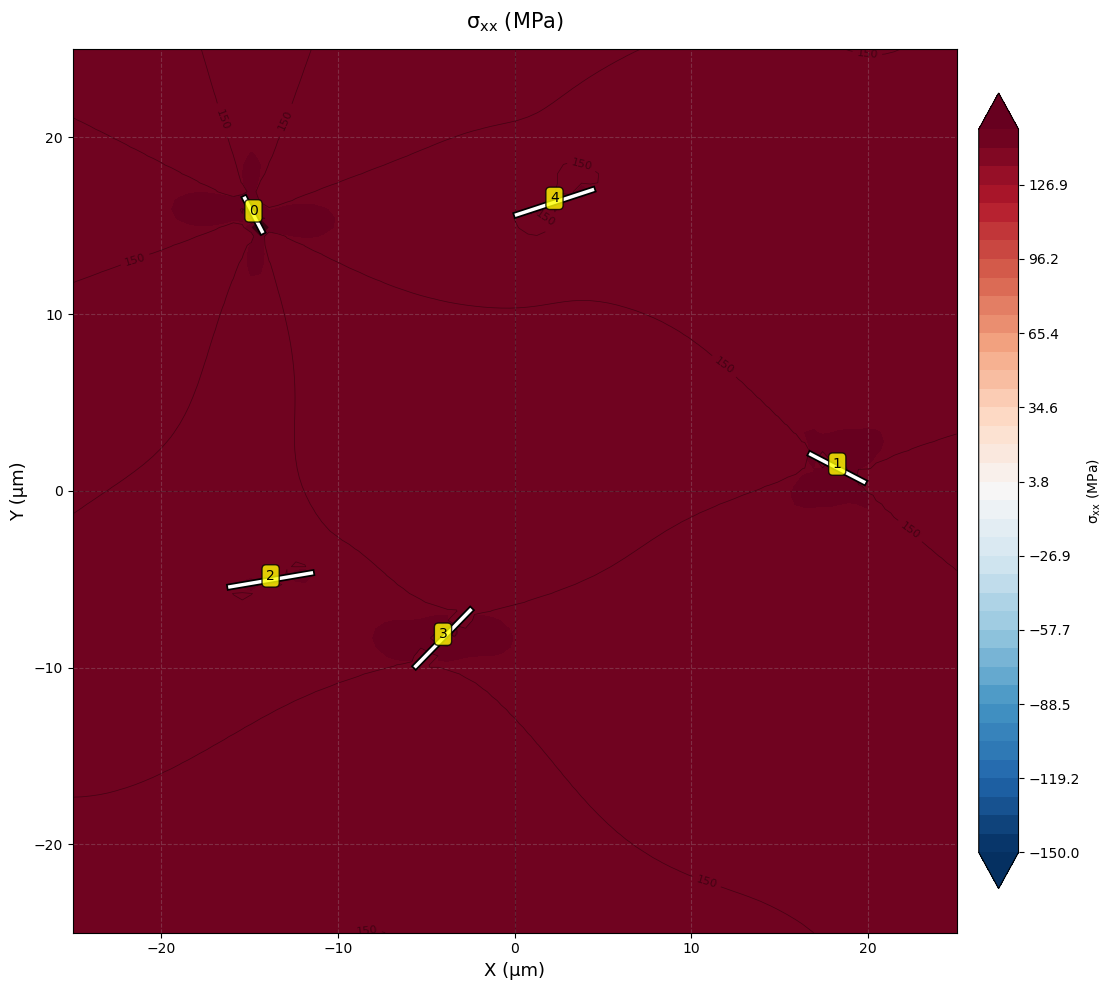


Step 6
Saved: C:\Users\Owner\Documents\Repos\Fracture\MulticracksCpp\output\sigma_yy_step6.png


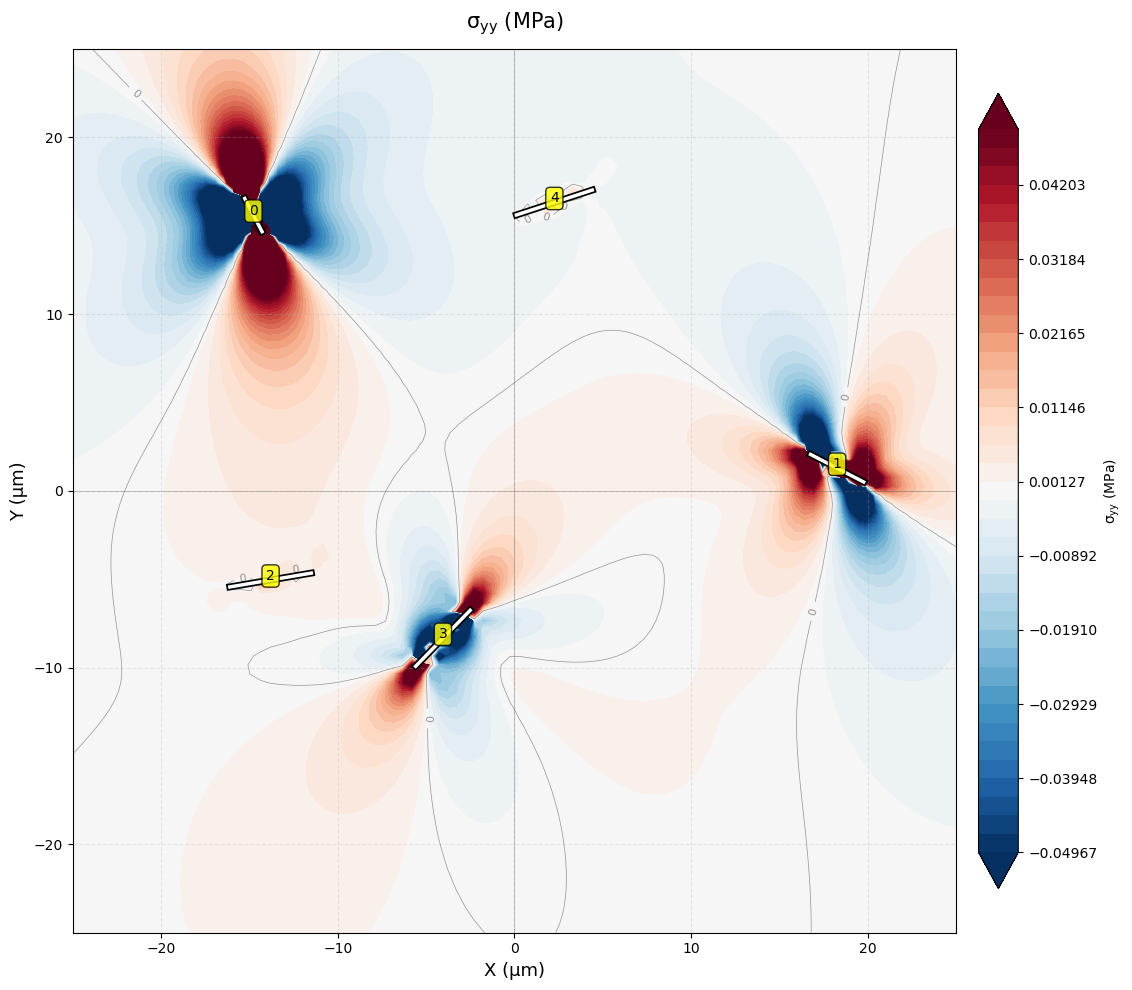

Saved: C:\Users\Owner\Documents\Repos\Fracture\MulticracksCpp\output\sigma_xx_step6.png


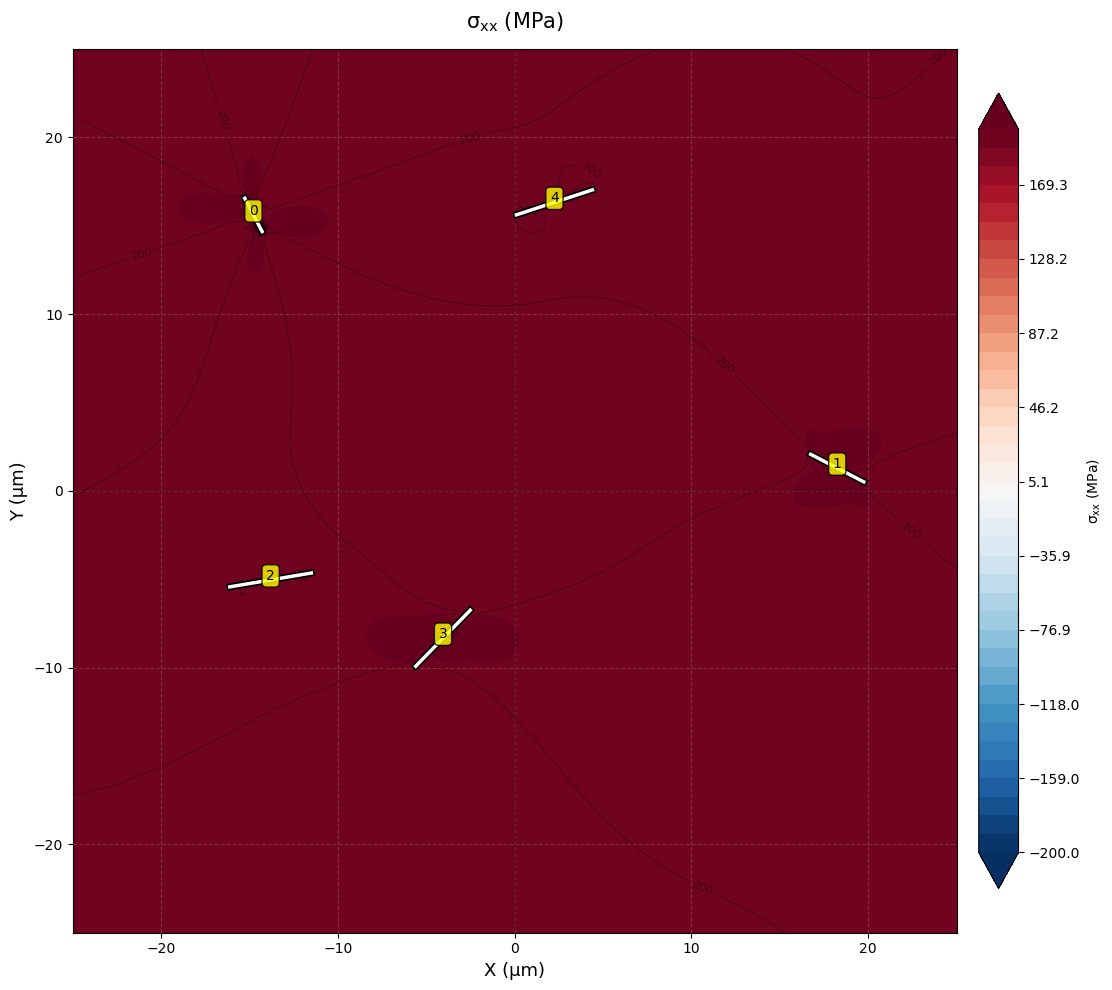


Step 8
Saved: C:\Users\Owner\Documents\Repos\Fracture\MulticracksCpp\output\sigma_yy_step8.png


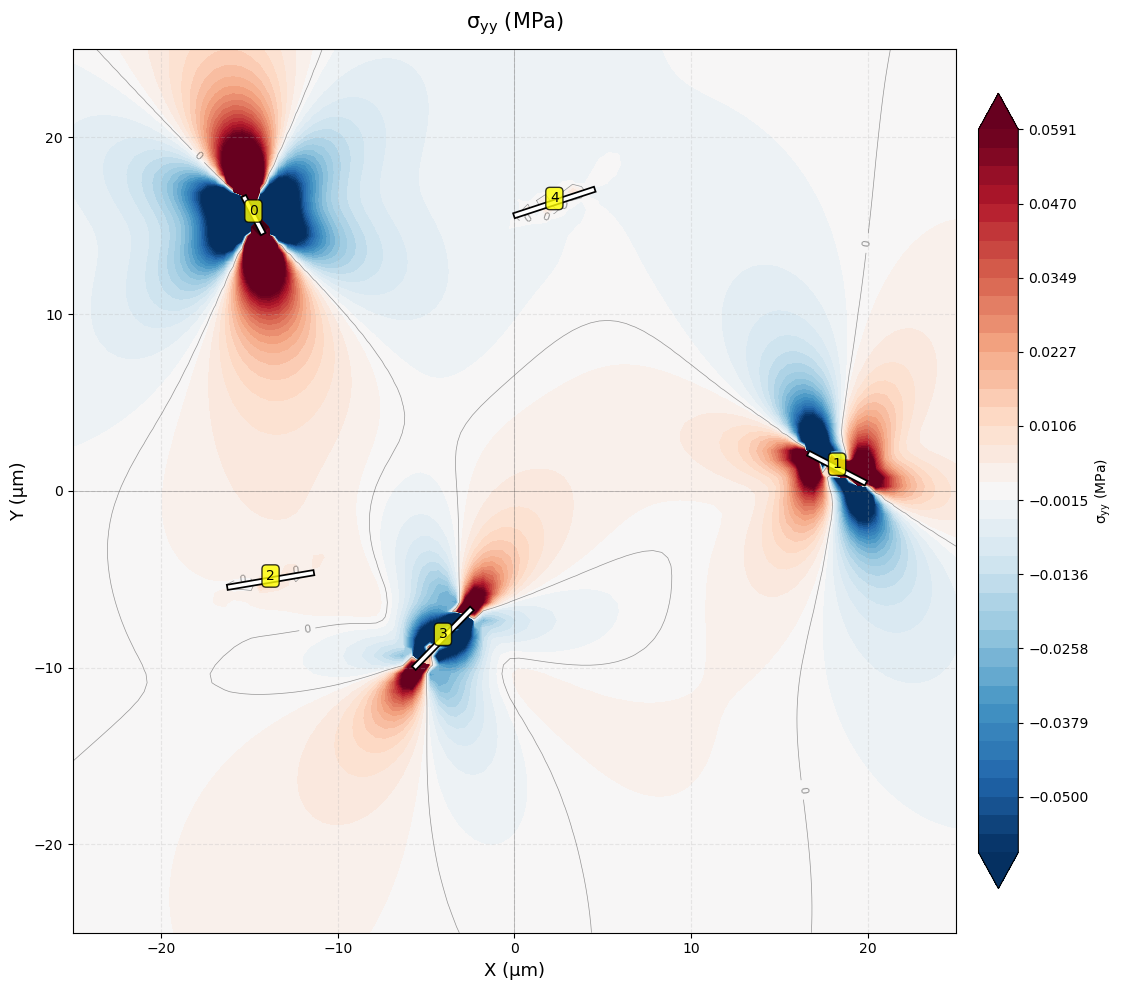

Saved: C:\Users\Owner\Documents\Repos\Fracture\MulticracksCpp\output\sigma_xx_step8.png


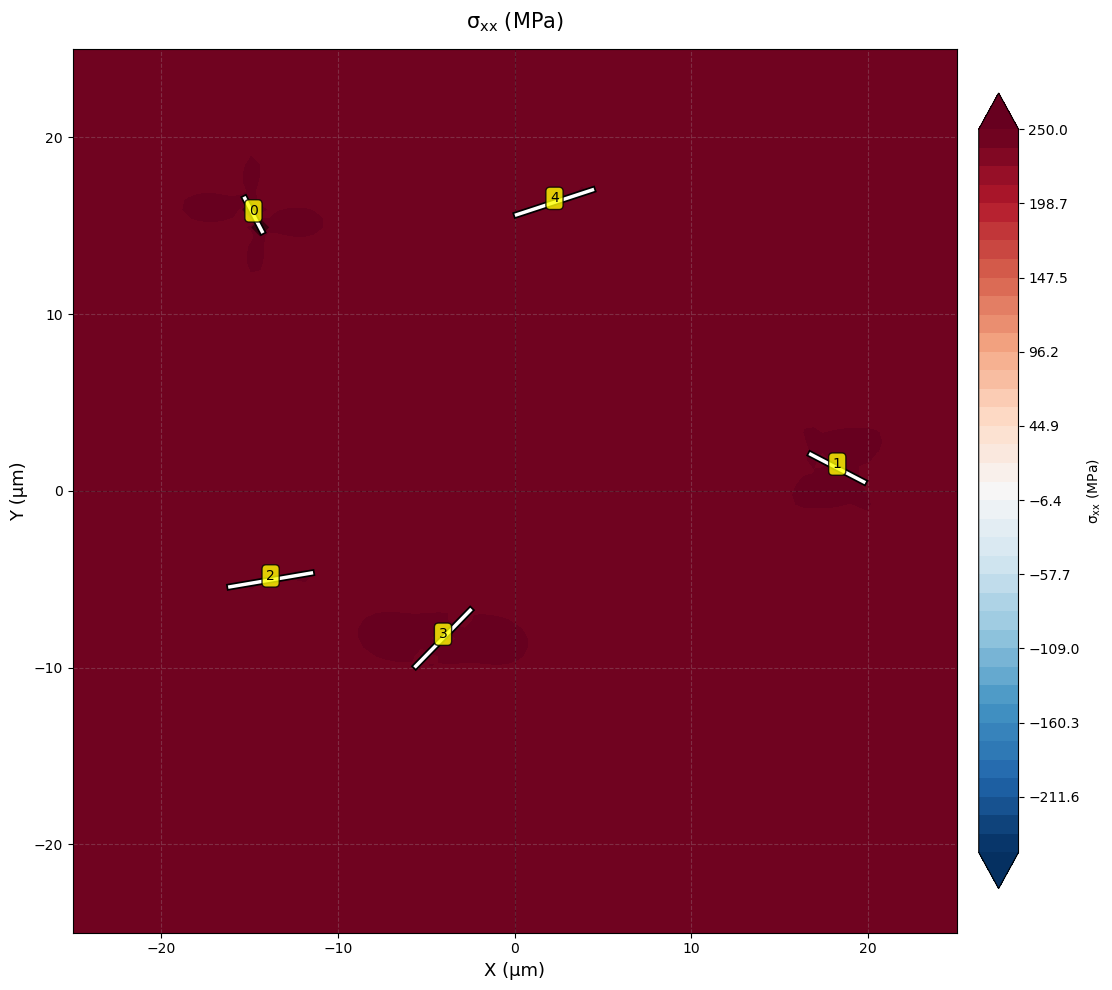


Step 10
Saved: C:\Users\Owner\Documents\Repos\Fracture\MulticracksCpp\output\sigma_yy_step10.png


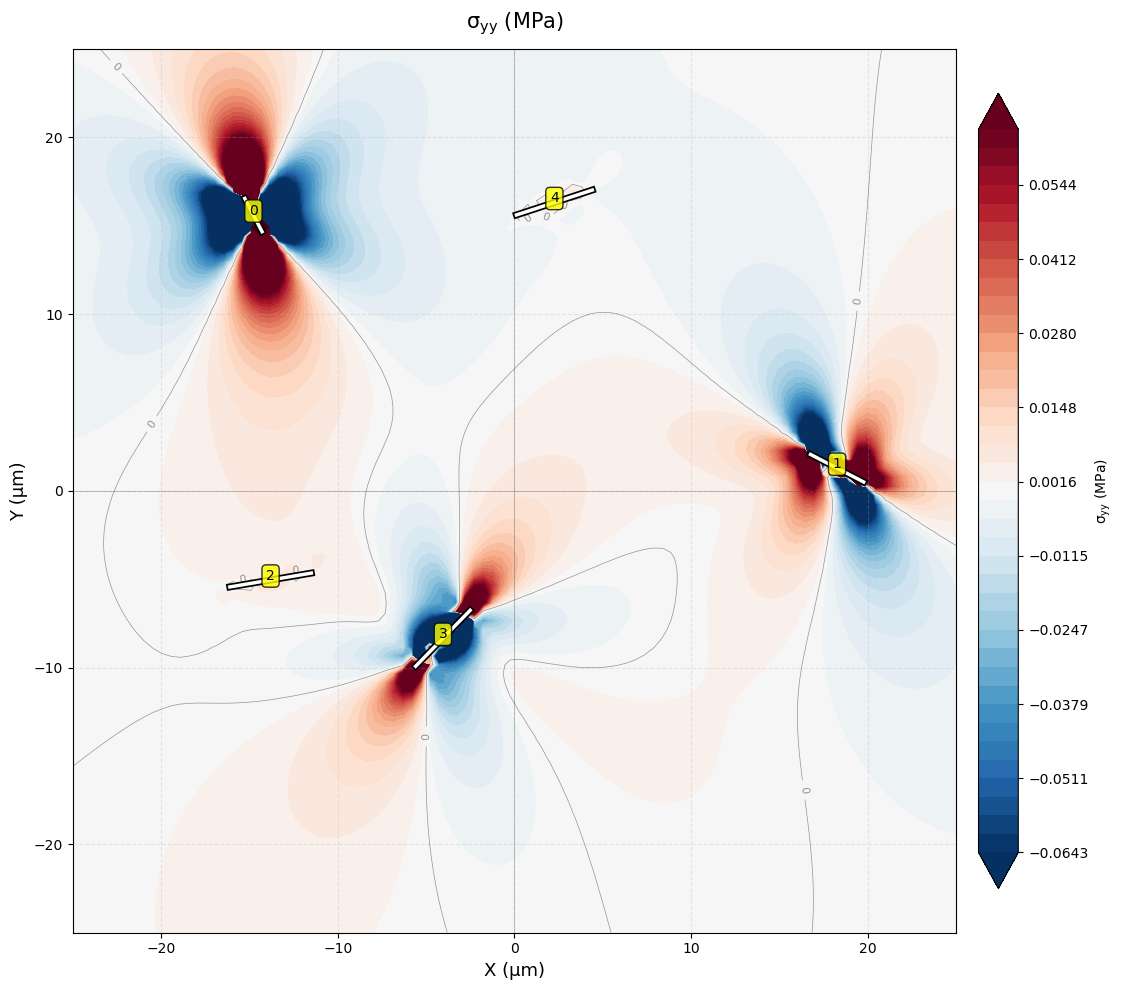

Saved: C:\Users\Owner\Documents\Repos\Fracture\MulticracksCpp\output\sigma_xx_step10.png


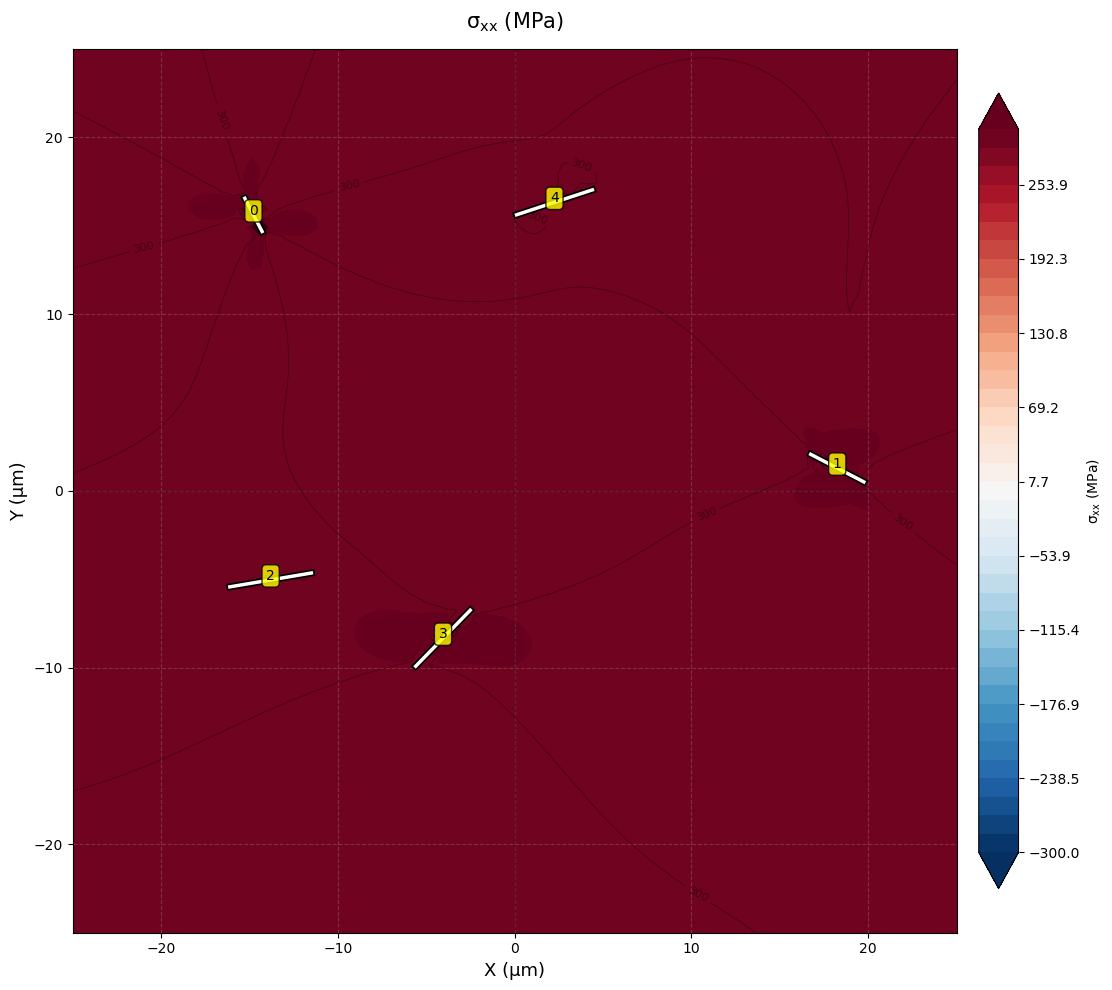

In [3]:
# Cell 3: Plot results
import glob

# Find all data files
data_files = sorted(glob.glob(os.path.join(output_dir, 'field_*.dat')))
print(f"Found {len(data_files)} data files")

# Plot selected steps
steps_to_plot = [0, 2, 4, 6, 8, 10]

for step in steps_to_plot:
    filename = os.path.join(output_dir, f'field_{step}.dat')
    
    if os.path.exists(filename):
        print(f"\n{'='*60}")
        print(f"Step {step}")
        print('='*60)
        
        # Plot sigma_yy
        plot_stress_field(filename, 'sigma_yy', 
                         os.path.join(output_dir, f'sigma_yy_step{step}.png'))
        
        # Plot sigma_xx
        plot_stress_field(filename, 'sigma_xx',
                         os.path.join(output_dir, f'sigma_xx_step{step}.png'))
    else:
        print(f"File not found: {filename}")

Saved: C:\Users\Owner\Documents\Repos\Fracture\MulticracksCpp\output\comparison_step10.png


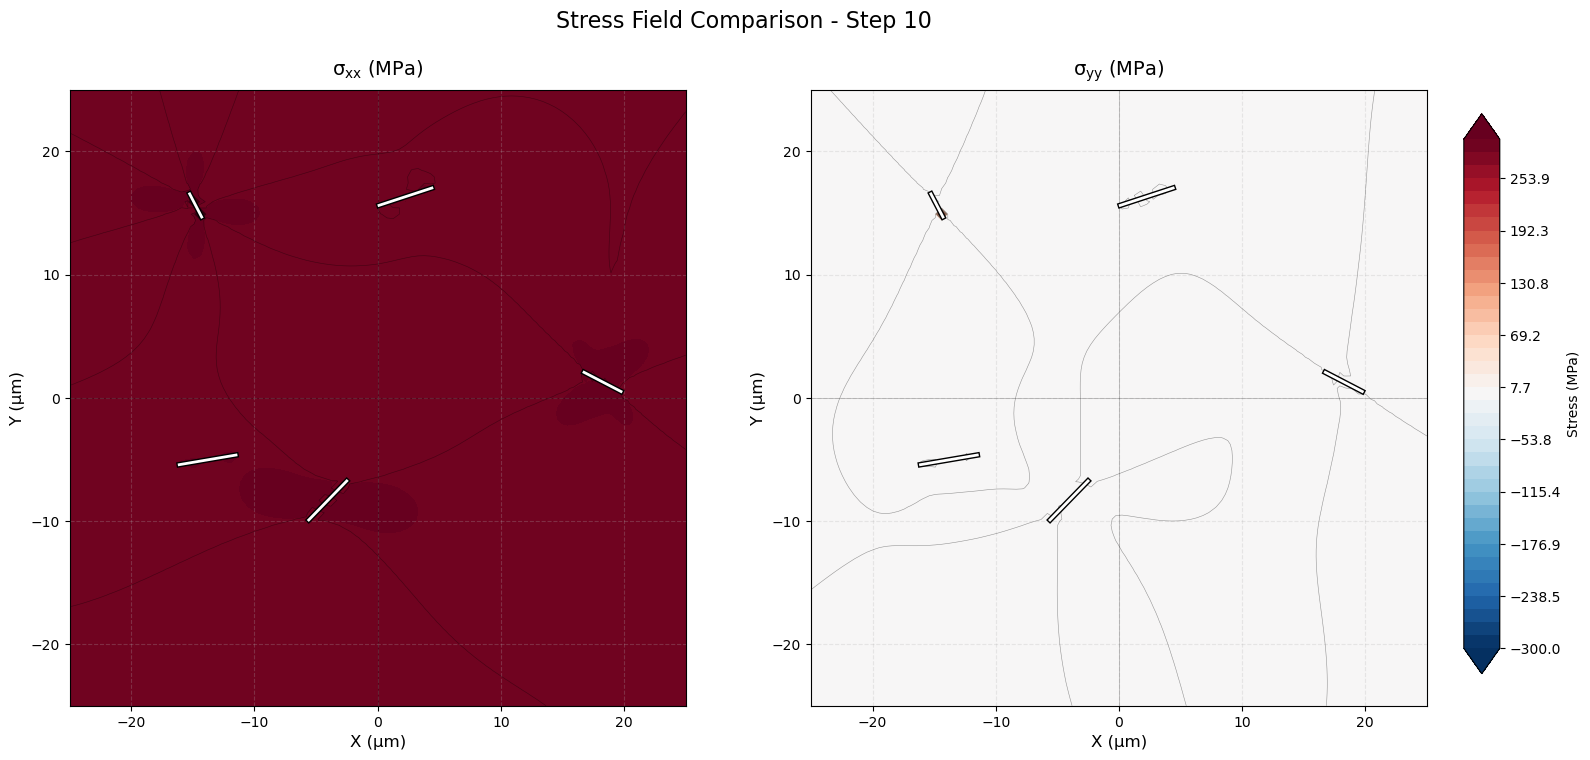

In [4]:
# Cell 4: Side-by-side comparison for a specific step
def plot_comparison(step=10):
    """Plot sigma_xx and sigma_yy side by side"""
    
    filename = os.path.join(output_dir, f'field_{step}.dat')
    
    if not os.path.exists(filename):
        print(f"File not found: {filename}")
        return
    
    # Load data
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    grid_data = []
    crack_data = []
    mode = 'grid'
    
    for line in lines:
        parts = line.strip().split()
        if not parts:
            continue
        values = [float(x) for x in parts]
        
        if values[0] == -999:
            mode = 'crack'
            continue
        elif values[0] == -998:
            break
        
        if mode == 'grid':
            grid_data.append(values)
        elif mode == 'crack':
            crack_data.append(values)
    
    grid = np.array(grid_data)
    cracks = np.array(crack_data) if crack_data else np.array([])
    
    x, y = grid[:, 0], grid[:, 1]
    sigma_xx, sigma_yy = grid[:, 2], grid[:, 3]
    
    unique_x, unique_y = np.unique(x), np.unique(y)
    nx, ny = len(unique_x), len(unique_y)
    
    X, Y = x.reshape(ny, nx), y.reshape(ny, nx)
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    
    # Common color scale
    all_stress = np.concatenate([sigma_xx, sigma_yy])
    vmax = np.percentile(np.abs(all_stress), 98) / 1e6
    vmin = -vmax
    levels = np.linspace(vmin, vmax, 40)
    
    # Plot sigma_xx
    Z_xx = sigma_xx.reshape(ny, nx) / 1e6
    contourf1 = ax1.contourf(X*1e6, Y*1e6, Z_xx, levels=levels, 
                            cmap='RdBu_r', extend='both')
    ax1.contour(X*1e6, Y*1e6, Z_xx, levels=12, colors='black', 
               linewidths=0.4, alpha=0.4)
    
    # Plot sigma_yy
    Z_yy = sigma_yy.reshape(ny, nx) / 1e6
    contourf2 = ax2.contourf(X*1e6, Y*1e6, Z_yy, levels=levels, 
                            cmap='RdBu_r', extend='both')
    ax2.contour(X*1e6, Y*1e6, Z_yy, levels=12, colors='black', 
               linewidths=0.4, alpha=0.4)
    
    # Plot cracks on both
    for ax in [ax1, ax2]:
        if len(cracks) > 0:
            for i, crack in enumerate(cracks):
                cx, cy, length, angle = crack
                dx = length/2 * np.cos(angle)
                dy = length/2 * np.sin(angle)
                x1, y1 = (cx - dx)*1e6, (cy - dy)*1e6
                x2, y2 = (cx + dx)*1e6, (cy + dy)*1e6
                
                ax.plot([x1, x2], [y1, y2], 'k-', linewidth=4, zorder=100)
                ax.plot([x1, x2], [y1, y2], 'w-', linewidth=2, zorder=101)
        
        ax.set_xlabel('X (μm)', fontsize=12, weight='bold')
        ax.set_ylabel('Y (μm)', fontsize=12, weight='bold')
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.25, linestyle='--')
        ax.axhline(0, color='k', linewidth=0.5, alpha=0.3)
        ax.axvline(0, color='k', linewidth=0.5, alpha=0.3)
    
    ax1.set_title(r'$\sigma_{xx}$ (MPa)', fontsize=14, weight='bold', pad=10)
    ax2.set_title(r'$\sigma_{yy}$ (MPa)', fontsize=14, weight='bold', pad=10)
    
    # Colorbar
    fig.subplots_adjust(right=0.88)
    cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(contourf2, cax=cbar_ax, label='Stress (MPa)')
    
    plt.suptitle(f'Stress Field Comparison - Step {step}', 
                fontsize=16, weight='bold', y=0.98)
    
    output_file = os.path.join(output_dir, f'comparison_step{step}.png')
    plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Saved: {output_file}")
    
    plt.show()

# Create comparison plot
plot_comparison(step=10)